# Notebook 8 — Hybrid Model 2: Clustering-Aware Distribution Harmonisation
Groups records by **age cluster** (young / middle / senior), blends cluster-specific with population `fitness_level` distribution, then corrects violations deterministically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df          = pd.read_csv('../data/t_close_anonymized.csv')
df_original = pd.read_csv('../data/raw_fitness_data.csv')

quasi_identifiers   = ['age', 'region', 'activity']
sensitive_attribute = 'fitness_level'
fitness_classes     = ['fit', 'moderately_fit', 'unfit']
t_threshold         = 0.25

assert 'fitness_level' in df.columns, 'Run Notebooks 1-4 first.'
print(f'✅ Data loaded — shape: {df.shape}')
print('\nfitness_level distribution:')
print(df['fitness_level'].value_counts())

✅ Data loaded — shape: (7000, 11)

fitness_level distribution:
fitness_level
moderately_fit    4015
fit               1504
unfit             1481
Name: count, dtype: int64


In [2]:
# Population reference distribution (fitness_level only)
pop_fl_dist = df_original['fitness_level'].value_counts(normalize=True)
pop_fl_dist = pop_fl_dist.reindex(fitness_classes, fill_value=0)


def tvd(p, q):
    keys = q.index
    p_a = p.reindex(keys, fill_value=0)
    return 0.5 * sum(abs(p_a[i] - q[i]) for i in keys)


def get_age_cluster(age_range):
    try:
        low = int(str(age_range).split('-')[0])
        if low < 30:  return 'young'
        elif low < 50: return 'middle'
        else:          return 'senior'
    except:
        return 'middle'


print('✅ Helper functions defined')

✅ Helper functions defined


In [3]:
# Analyse baseline violations
group_rows = []
for gk, gd in df.groupby(quasi_identifiers):
    gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)
    d = tvd(gd_dist, pop_fl_dist)
    group_rows.append({'group': gk, 'age_range': gk[0], 'tvd': d, 'violates': d > t_threshold, 'size': len(gd)})

group_df = pd.DataFrame(group_rows)
group_df['age_cluster'] = group_df['age_range'].apply(get_age_cluster)

print(f'Total groups: {len(group_df)},  violating: {group_df["violates"].sum()}')
print('\nGroups per age cluster:')
print(group_df.groupby('age_cluster')['violates'].agg(['count', 'sum']))

Total groups: 143,  violating: 49

Groups per age cluster:
             count  sum
age_cluster            
middle          48   17
senior          59   22
young           36   10


In [4]:
# Add age_cluster to working copy
df_h2 = df.copy()
df_h2['age_cluster'] = df_h2['age'].apply(get_age_cluster)

# Cluster-specific target distributions (50/50 blend with population)
cluster_targets = {}
for clust, cdata in df_h2.groupby('age_cluster'):
    clust_dist = cdata['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)
    target     = (0.5 * clust_dist + 0.5 * pop_fl_dist)
    cluster_targets[clust] = target
    print(f'  {clust}: {target.round(3).to_dict()}')

  middle: {'fit': 0.206, 'moderately_fit': 0.604, 'unfit': 0.189}
  senior: {'fit': 0.133, 'moderately_fit': 0.529, 'unfit': 0.338}
  young: {'fit': 0.266, 'moderately_fit': 0.584, 'unfit': 0.15}


In [5]:
def harmonise(group_data, target_dist, max_corr, fc):
    """Returns list of (index, new_class) corrections. Deterministic."""
    corrections = []
    curr_dist = group_data['fitness_level'].value_counts(normalize=True).reindex(fc, fill_value=0)
    diff = curr_dist - target_dist

    if diff.max() <= 0.05:
        return corrections

    over_c  = diff.idxmax()
    under_c = diff.idxmin()

    over_rec = group_data[group_data['fitness_level'] == over_c]
    n = min(max_corr, max(1, len(over_rec) - 1))

    if under_c == 'fit':
        targets = over_rec.nlargest(n, 'steps').index
    elif under_c == 'unfit':
        targets = over_rec.nsmallest(n, 'steps').index
    else:
        med = over_rec['steps'].median()
        targets = (over_rec['steps'] - med).abs().nsmallest(n).index

    return [(idx, under_c) for idx in targets]


print('✅ Harmonisation function defined')

✅ Harmonisation function defined


In [6]:
# ---------------------------------------------------------------
# HYBRID 2 — Clustering-aware correction
# Each violating group is corrected towards its age-cluster target
# (rather than the global population target used in Hybrid 1).
# ---------------------------------------------------------------
violation_dict = {r['group']: r for _, r in group_df.iterrows()}
total_corr = 0
groups_corr = 0

for gk, gd in df_h2.groupby(quasi_identifiers):
    if len(gd) < 4 or gk not in violation_dict:
        continue
    vd = violation_dict[gk]
    if not vd['violates']:
        continue

    cluster   = vd['age_cluster']
    target    = cluster_targets.get(cluster, pop_fl_dist)
    max_c     = max(1, int(len(gd) * 0.25))
    corr_list = harmonise(gd, target, max_c, fitness_classes)

    for idx, new_cls in corr_list:
        df_h2.loc[idx, 'fitness_level'] = new_cls

    total_corr  += len(corr_list)
    groups_corr += (1 if corr_list else 0)

print(f'✅ Hybrid 2 complete — records adjusted: {total_corr}, groups corrected: {groups_corr}')
print('\nfitness_level distribution after Hybrid 2:')
print(df_h2['fitness_level'].value_counts())

✅ Hybrid 2 complete — records adjusted: 507, groups corrected: 44

fitness_level distribution after Hybrid 2:
fitness_level
moderately_fit    4477
fit               1270
unfit             1253
Name: count, dtype: int64


In [7]:
viol_after = 0
tvd_after  = []
for _, gd in df_h2.groupby(quasi_identifiers):
    gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)
    d = tvd(gd_dist, pop_fl_dist)
    tvd_after.append(d)
    if d > t_threshold:
        viol_after += 1

print(f'Violations after Hybrid 2: {viol_after} / {len(tvd_after)}')
print(f'Mean TVD after: {np.mean(tvd_after):.4f}')

Violations after Hybrid 2: 18 / 143
Mean TVD after: 0.1989


In [8]:
# Inference attack simulation
def inference_attack_accuracy(df_in, quasi_ids):
    correct = 0
    for _, gd in df_in.groupby(quasi_ids):
        predicted = gd['fitness_level'].mode().iloc[0]
        correct  += (gd['fitness_level'] == predicted).sum()
    return correct / len(df_in)


acc_before = inference_attack_accuracy(df, quasi_identifiers)
acc_after  = inference_attack_accuracy(df_h2.drop(columns=['age_cluster']), quasi_identifiers)

print(f'Inference attack accuracy BEFORE Hybrid 2: {acc_before:.4f} ({100*acc_before:.1f}%)')
print(f'Inference attack accuracy AFTER  Hybrid 2: {acc_after:.4f} ({100*acc_after:.1f}%)')
print(f'Attack accuracy reduction: {100*(acc_before - acc_after):.1f} pp')

Inference attack accuracy BEFORE Hybrid 2: 0.6793 (67.9%)
Inference attack accuracy AFTER  Hybrid 2: 0.6434 (64.3%)
Attack accuracy reduction: 3.6 pp


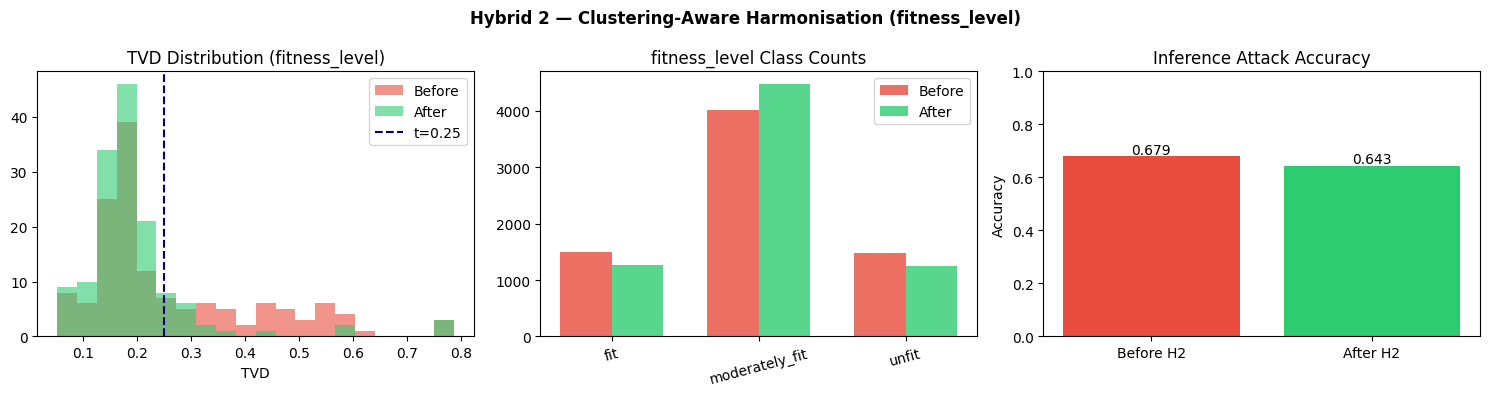

✅ Saved: ../results/hybrid2_analysis.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tvd_before = group_df['tvd'].tolist()

axes[0].hist(tvd_before, bins=20, alpha=0.6, color='#e74c3c', label='Before')
axes[0].hist(tvd_after,  bins=20, alpha=0.6, color='#2ecc71', label='After')
axes[0].axvline(x=t_threshold, color='navy', linestyle='--', label=f't={t_threshold}')
axes[0].set_title('TVD Distribution (fitness_level)')
axes[0].set_xlabel('TVD'); axes[0].legend()

x = np.arange(3); w = 0.35
bc = df['fitness_level'].value_counts().reindex(fitness_classes).values
ac = df_h2['fitness_level'].value_counts().reindex(fitness_classes).values
axes[1].bar(x - w/2, bc, w, label='Before', color='#e74c3c', alpha=0.8)
axes[1].bar(x + w/2, ac, w, label='After',  color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(fitness_classes, rotation=15)
axes[1].set_title('fitness_level Class Counts')
axes[1].legend()

axes[2].bar(['Before H2', 'After H2'], [acc_before, acc_after], color=['#e74c3c', '#2ecc71'])
axes[2].set_ylim(0, 1)
axes[2].set_title('Inference Attack Accuracy')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate([acc_before, acc_after]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.suptitle('Hybrid 2 — Clustering-Aware Harmonisation (fitness_level)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/hybrid2_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/hybrid2_analysis.png')

In [10]:
# Drop helper column before saving
df_h2_save = df_h2.drop(columns=['age_cluster'])
df_h2_save.to_csv('../data/hybrid2_result.csv', index=False)
print('✅ Saved: ../data/hybrid2_result.csv')

h2_metrics = {
    'method': 'Hybrid 2 — Clustering-Aware Harmonisation',
    'sensitive_attribute': 'fitness_level',
    'inference_attack_accuracy': float(acc_after),
    'inference_attack_accuracy_before': float(acc_before),
    'attack_accuracy_reduction': float(acc_before - acc_after),
    'violations_after': viol_after,
    'mean_tvd': float(np.mean(tvd_after)),
    'total_adjustments': total_corr,
    'data_loss_percent': 0.0
}

with open('../results/hybrid2_metrics.json', 'w') as f:
    json.dump(h2_metrics, f, indent=2)

print('\nHybrid 2 summary:')
for k, v in h2_metrics.items():
    print(f'  {k}: {v}')

✅ Saved: ../data/hybrid2_result.csv

Hybrid 2 summary:
  method: Hybrid 2 — Clustering-Aware Harmonisation
  sensitive_attribute: fitness_level
  inference_attack_accuracy: 0.6434285714285715
  inference_attack_accuracy_before: 0.6792857142857143
  attack_accuracy_reduction: 0.03585714285714281
  violations_after: 18
  mean_tvd: 0.19887052353517767
  total_adjustments: 507
  data_loss_percent: 0.0
